<a href="https://colab.research.google.com/github/A-Peoples/DSRP_Project_26/blob/main/DSRP_2026_Earthquakes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
link = "https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Earthquakes/earthquakes.csv"
eq_df = pd.read_csv(link)

In [4]:
eq_df.info()#.describe()

null_eq_df = eq_df.loc[eq_df['magType'].isnull()]

null_eq_df

eq_df_dd = eq_df.drop_duplicates()

#eq_df_dd.shape
#There are no duplicates

#eq_df.shape

eq_df_dd

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178752 entries, 0 to 178751
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   time       178752 non-null  object 
 1   latitude   178752 non-null  float64
 2   longitude  178752 non-null  float64
 3   depth      178752 non-null  float64
 4   mag        178752 non-null  float64
 5   magType    178751 non-null  object 
 6   net        178752 non-null  object 
 7   id         178752 non-null  object 
 8   place      178752 non-null  object 
 9   type       178752 non-null  object 
dtypes: float64(4), object(6)
memory usage: 13.6+ MB


,time,latitude,longitude,depth,mag,magType,net,id,place,type
0,2017-02-21 01:41:11.800000+00:00,-20.3521,-177.7955,512.760,4.4,mb,us,us1000860s,"283 km WNW of Haveluloto, Tonga",earthquake
1,2020-06-10 12:58:33.535000+00:00,69.3927,-143.9529,12.500,3.1,ml,ak,ak0207g4jxgn,"83 km S of Kaktovik, Alaska",earthquake
2,2020-11-29 01:02:57.577000+00:00,3.7184,126.3073,122.480,4.2,mb,us,us7000cmmz,"208 km SSE of Sarangani, Philippines",earthquake
3,2015-12-11 22:07:37.420000+00:00,-19.7988,-69.2959,107.450,4.3,mb,us,us20004hcx,"100 km ENE of Iquique, Chile",earthquake
4,2023-07-23 12:33:29.354000+00:00,-8.6271,111.1186,96.623,5.1,mb,us,us7000khss,"Java, Indonesia",earthquake
...,...,...,...,...,...,...,...,...,...,...
178747,2016-02-20 14:56:41.110000+00:00,4.5556,-32.3953,10.000,4.7,mb,us,us10004s3r,central Mid-Atlantic Ridge,earthquake
178748,2016-11-20 13:53:04.020000+00:00,-44.2306,39.2988,12.680,4.6,mb,us,us10007dq5,Prince Edward Islands region,earthquake
178749,2015-12-25 05:14:42.420000+00:00,6.7295,126.5013,67.450,4.6,mb,us,us10004b9j,"24 km SE of Bobon, Philippines",earthquake
178750,2021-01-27 10:40:25.888000+00:00,-5.1167,103.6804,44.460,4.9,mb,us,us7000d3n4,"121 km SSW of Baturaja, Indonesia",earthquake


In [50]:
instances = eq_df.shape[0]
counter = 0
city = []
country = []
year = []

for i in range(instances):
  country.append(eq_df['place'][counter].split(", ")[-1])
  counter += 1
counter = 0

for i in range(instances):
  if "," in (eq_df['place'][counter]):
    city.append(eq_df['place'][counter].split()[-2].split(",")[0])
  else:
    city.append(eq_df['place'][counter])
  counter += 1
counter = 0
for i in range(instances):
  year.append(str(eq_df['time'][counter].split('-')[0]))
  counter += 1

eq_df['city'] = city
eq_df['country'] = country
eq_df['year'] = year
eq_df

,time,latitude,longitude,depth,mag,magType,net,id,place,type,city,country,year
0,2017-02-21 01:41:11.800000+00:00,-20.3521,-177.7955,512.760,4.4,mb,us,us1000860s,"283 km WNW of Haveluloto, Tonga",earthquake,Haveluloto,Tonga,2017
1,2020-06-10 12:58:33.535000+00:00,69.3927,-143.9529,12.500,3.1,ml,ak,ak0207g4jxgn,"83 km S of Kaktovik, Alaska",earthquake,Kaktovik,Alaska,2020
2,2020-11-29 01:02:57.577000+00:00,3.7184,126.3073,122.480,4.2,mb,us,us7000cmmz,"208 km SSE of Sarangani, Philippines",earthquake,Sarangani,Philippines,2020
3,2015-12-11 22:07:37.420000+00:00,-19.7988,-69.2959,107.450,4.3,mb,us,us20004hcx,"100 km ENE of Iquique, Chile",earthquake,Iquique,Chile,2015
4,2023-07-23 12:33:29.354000+00:00,-8.6271,111.1186,96.623,5.1,mb,us,us7000khss,"Java, Indonesia",earthquake,Java,Indonesia,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...
178747,2016-02-20 14:56:41.110000+00:00,4.5556,-32.3953,10.000,4.7,mb,us,us10004s3r,central Mid-Atlantic Ridge,earthquake,central Mid-Atlantic Ridge,central Mid-Atlantic Ridge,2016
178748,2016-11-20 13:53:04.020000+00:00,-44.2306,39.2988,12.680,4.6,mb,us,us10007dq5,Prince Edward Islands region,earthquake,Prince Edward Islands region,Prince Edward Islands region,2016
178749,2015-12-25 05:14:42.420000+00:00,6.7295,126.5013,67.450,4.6,mb,us,us10004b9j,"24 km SE of Bobon, Philippines",earthquake,Bobon,Philippines,2015
178750,2021-01-27 10:40:25.888000+00:00,-5.1167,103.6804,44.460,4.9,mb,us,us7000d3n4,"121 km SSW of Baturaja, Indonesia",earthquake,Baturaja,Indonesia,2021


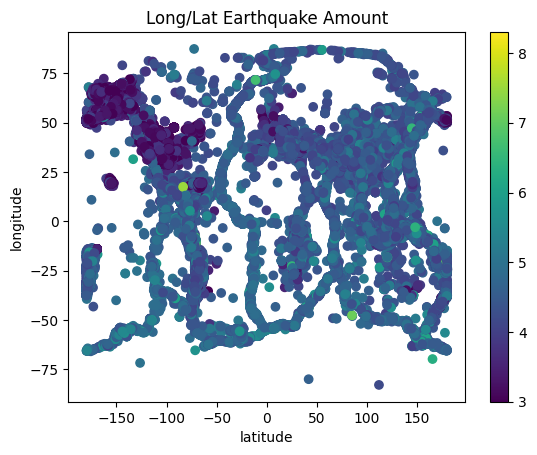

In [51]:
graph_data = eq_df[['latitude', 'longitude', 'mag']]
plt.scatter(graph_data['longitude'], graph_data['latitude'], c=graph_data['mag'])
plt.colorbar()
plt.xlabel("latitude")
plt.ylabel('longitude')
plt.title('Long/Lat Earthquake Amount')
plt.show()

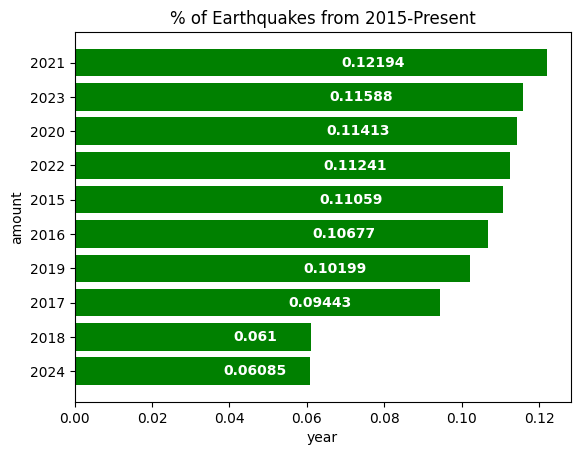

In [84]:
year_graph = eq_df.groupby(['year']).agg({"mag": 'count'}).reset_index()
year_graph['eq%'] = (year_graph['mag'] / year_graph['mag'].sum()).round(5)
year_graph = year_graph.sort_values(by='eq%', ascending=True).reset_index()
fig, ax = plt.subplots()


x = plt.barh(year_graph['year'], year_graph['eq%'], color="green")
plt.xlabel("year")
plt.ylabel('amount')
plt.title('% of Earthquakes from 2015-Present')
plt.bar_label(x, padding=45, color='white', label_type="center", fontweight='bold')
plt.show()
#ax.bar('')